In [1]:
!pip install efficientnet

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import shutil
from tqdm import tqdm
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import keras
from keras import preprocessing
from keras import layers
from keras import models, Model
from tqdm import tqdm
from keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, EfficientNetB3, DenseNet121, EfficientNetB0, EfficientNetB1
from tensorflow.keras.layers import Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input, Activation
from keras.models import Sequential

%matplotlib inline
sns.set_style('darkgrid')
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_csv('C:/Users/harma/OneDrive/Desktop/project2/data2/balanced_labels_pv.csv')
test_df = pd.read_csv('C:/Users/harma/OneDrive/Desktop/project2/data2/test.csv')
print(train_df.shape)
print(test_df.shape)

(6008, 2)
(1928, 1)


In [4]:
train_df.head()

,id_code,diagnosis
0,ef5155990874.png,0
1,0a85a1e8f9e9.png,0
2,6a2642131e4a.png,0
3,8a8a251770cd.png,0
4,ac1667fac512.png,0


In [5]:
train_df.tail()

,id_code,diagnosis
6003,b746a6681ba9_aug_370_aug_0.png,2
6004,6cbc3dad809c_aug_5.png,2
6005,9ad92f1c1542_aug_2.png,2
6006,c52bb7343387_aug_193_aug_1.png,2
6007,8aab201c0691_aug_1.png,2


In [6]:
test_df.head()


,id_code
0,0005cfc8afb6
1,003f0afdcd15
2,006efc72b638
3,00836aaacf06
4,009245722fa4


In [7]:
train_df.diagnosis.value_counts()

diagnosis
2    2700
1     920
4     845
0     800
3     743
Name: count, dtype: int64

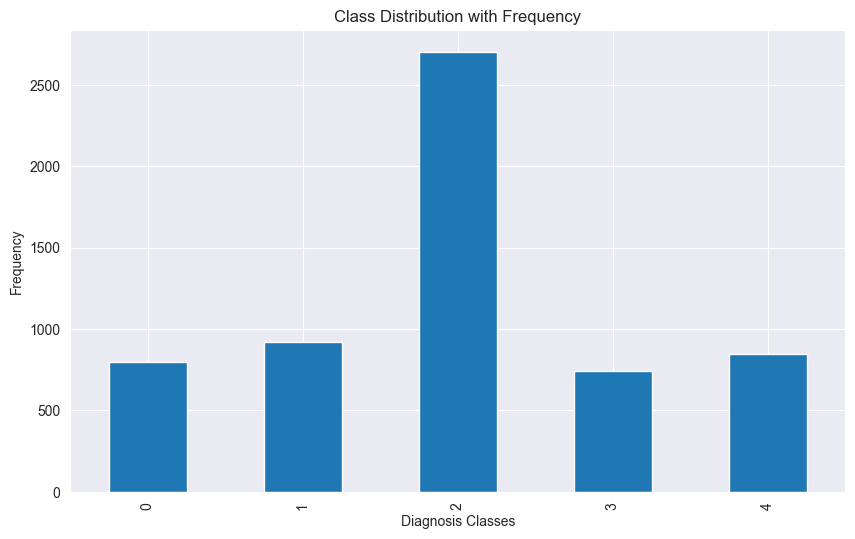

In [8]:
train_df.diagnosis.value_counts().sort_index().plot(kind='bar', figsize=(10,6), grid= True)
plt.title('Class Distribution with Frequency')
plt.xlabel('Diagnosis Classes')
plt.ylabel('Frequency')
plt.show()

In [9]:
print('Displaying Image Codes and their Labels(Train)')
# train_df['id_code'] = train_df['id_code'] + '.png'
display(train_df.head())
print('Displaying Image Codes(Test)')
test_df['id_code'] = test_df['id_code'] + '.png'
display(test_df.head())

Displaying Image Codes and their Labels(Train)


,id_code,diagnosis
0,ef5155990874.png,0
1,0a85a1e8f9e9.png,0
2,6a2642131e4a.png,0
3,8a8a251770cd.png,0
4,ac1667fac512.png,0


Displaying Image Codes(Test)


,id_code
0,0005cfc8afb6.png
1,003f0afdcd15.png
2,006efc72b638.png
3,00836aaacf06.png
4,009245722fa4.png


In [10]:
train_images_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/train_images'
test_images_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/test_images/test_images'
preprocessed_train_images_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images'

In [11]:
def display_images_with_labels(dataframe, image_dir, num_images=10):
    sample_df = dataframe.sample(n=num_images)

    plt.figure(figsize=(20, 8))

    for i, row in enumerate(sample_df.iterrows()):
        idx, row_data = row
        img_path = os.path.join(image_dir, row_data['id_code'])
        label = row_data['diagnosis']

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"ID: {row_data['id_code']}\nLabel: {label}")
        plt.axis('off')

    plt.show()

display_images_with_labels(train_df, train_images_dir, num_images=10)

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


<Figure size 2000x800 with 0 Axes>

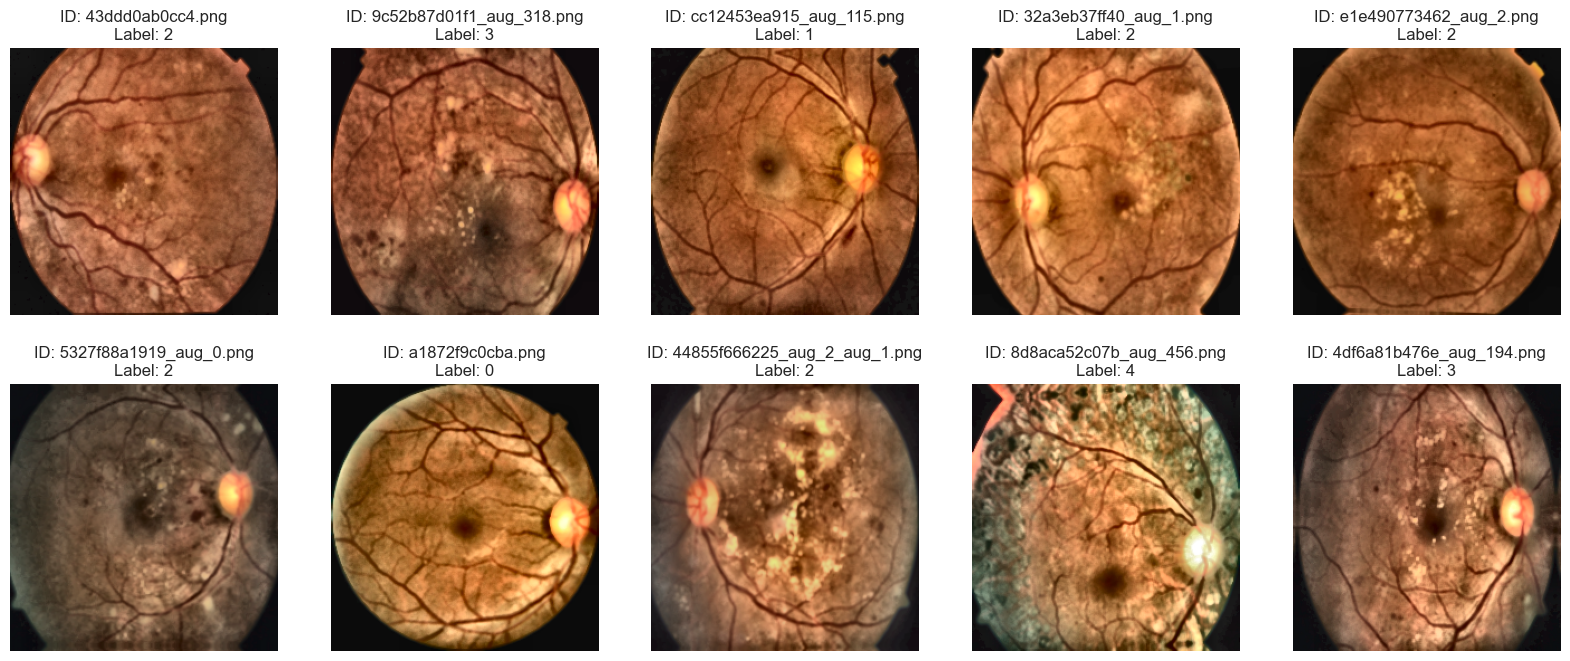

In [12]:
def display_images_with_labels(dataframe, image_dir, num_images=10):
    sample_df = dataframe.sample(n=num_images)

    plt.figure(figsize=(20, 8))

    for i, row in enumerate(sample_df.iterrows()):
        idx, row_data = row
        img_path = os.path.join(image_dir, row_data['id_code'])
        label = row_data['diagnosis']

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"ID: {row_data['id_code']}\nLabel: {label}")
        plt.axis('off')

    plt.show()

display_images_with_labels(train_df, preprocessed_train_images_dir, num_images=10)

In [13]:
# Paths
csv_path = "C:/Users/harma/OneDrive/Desktop/project2/data2/balanced_labels_pv.csv"
image_folder = "C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images"

# Load CSV
df = pd.read_csv(csv_path)

# Generate class pairs dynamically
classes = df['diagnosis'].unique()
class_pairs = [(i, j) for idx, i in enumerate(classes) for j in classes[idx + 1:]]

# Display generated class pairs
print("Generated Class Pairs:", class_pairs)

Generated Class Pairs: [(np.int64(0), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(3)), (np.int64(0), np.int64(4)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(1), np.int64(4)), (np.int64(2), np.int64(3)), (np.int64(2), np.int64(4)), (np.int64(3), np.int64(4))]


In [14]:
def load_data_for_binary_classification(class1, class2):
    """Loads images and labels for a binary classification task."""

    binary_df = df[df['diagnosis'].isin([class1, class2])]
    print(f"\n🔍 Checking dataset for {class1} vs. {class2} | Total samples: {len(binary_df)}")
    print(binary_df['diagnosis'].value_counts())

    images, labels = [], []
    for _, row in tqdm(binary_df.iterrows(), total=len(binary_df)):
        img_id = row['id_code']
        img_path = os.path.join(image_folder, img_id)

        if os.path.exists(img_path):
            image = cv2.imread(img_path)  # Read in BGR format
            if image is None:
                print(f"⚠️ OpenCV could not read: {img_path}")
                continue  # Skip unreadable images

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
            image = cv2.resize(image, (240, 240))  # Resize to 240x240
            images.append(image)
            labels.append(0 if row['diagnosis'] == class1 else 1)

    if not images:
        raise ValueError("❌ No images found. Check file paths or preprocessing.")

    images = np.array(images)
    labels = np.array(labels)

    print(f"✅ Loaded {len(images)} images successfully.")
    return images, labels

print("Image loading function defined successfully.")

Image loading function defined successfully.


In [15]:
print(f"📂 image_folder: {image_folder} | Type: {type(image_folder)}")

📂 image_folder: C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images | Type: <class 'str'>


In [16]:
def get_data_generators(class1, class2, batch_size=32):
    """Creates data generators for binary classification with augmentation."""

    X, y = load_data_for_binary_classification(class1, class2)

    binary_df = pd.DataFrame({"id_code": df[df['diagnosis'].isin([class1, class2])]['id_code'], "label": y})

    # Train-validation split
    train_df, val_df = train_test_split(binary_df, test_size=0.2, random_state=42, stratify=binary_df["label"])

    # Convert labels to string format (Fix for TypeError)
    train_df["label"] = train_df["label"].astype(str)
    val_df["label"] = val_df["label"].astype(str)

    # ImageDataGenerator for data augmentation (Training)
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.15,
        horizontal_flip=True,
        # height_shift_range=0.2,
        # width_shift_range=0.2,
        # vertical_flip=True,
        # shear_range=0.2,
        brightness_range = (0.7, 1.3),
        fill_mode = 'nearest',
    )

    # Validation generator (No augmentation)
    val_datagen = ImageDataGenerator(rescale=1./255)

    # Create train generator
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df, directory=image_folder, x_col="id_code", y_col="label", class_mode="binary", target_size=(240,240), batch_size=batch_size, shuffle=False)

    # Create validation generator
    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df, directory=image_folder, x_col="id_code", y_col="label", class_mode="binary", target_size=(240,240), batch_size=batch_size, shuffle=False)

    return train_generator, val_generator

print("Data generators function defined.")

Data generators function defined.


In [17]:
# Define class pair
class1, class2 = 0, 3  # Example classes

# Get generators
train_generator, val_generator = get_data_generators(class1, class2)

# Now, check the shape of batches
X_train_batch, y_train_batch = next(train_generator)
print("Train batch shape:", X_train_batch.shape, y_train_batch.shape)

X_val_batch, y_val_batch = next(val_generator)
print("Validation batch shape:", X_val_batch.shape, y_val_batch.shape)


🔍 Checking dataset for 0 vs. 3 | Total samples: 1543
diagnosis
0    800
3    743
Name: count, dtype: int64


100%|██████████| 1543/1543 [00:02<00:00, 581.68it/s]


✅ Loaded 1543 images successfully.
Found 1234 validated image filenames belonging to 2 classes.
Found 309 validated image filenames belonging to 2 classes.
Train batch shape: (32, 240, 240, 3) (32,)
Validation batch shape: (32, 240, 240, 3) (32,)


In [18]:
print(train_generator.samples)  # Should print a nonzero number
print(val_generator.samples)  # Should print a nonzero number

1234
309


In [19]:
import numpy as np
unique, counts = np.unique(val_generator.labels, return_counts=True)
print(unique, counts)

[0 1] [160 149]


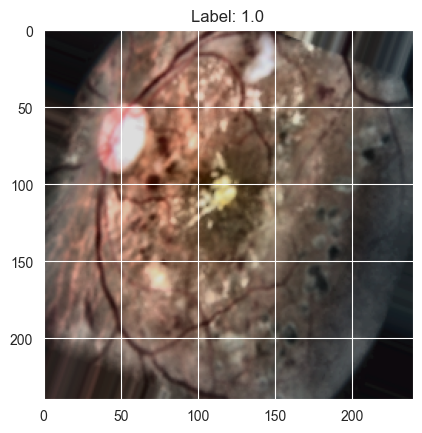

In [20]:
import matplotlib.pyplot as plt
x_batch, y_batch = next(train_generator)
plt.imshow(x_batch[0])
plt.title(f"Label: {y_batch[0]}")
plt.show()

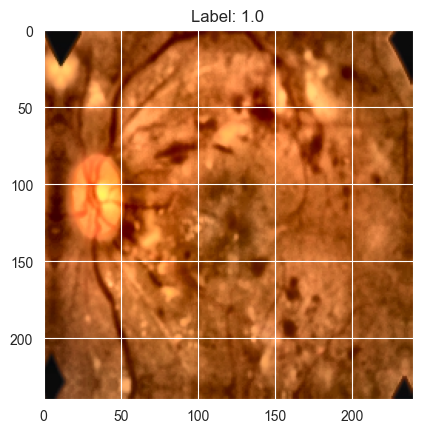

In [21]:
import matplotlib.pyplot as plt
x_batch, y_batch = next(val_generator)
plt.imshow(x_batch[0])
plt.title(f"Label: {y_batch[0]}")
plt.show()

In [22]:
def create_model():
    """Creates and compiles the EfficientNet model."""

    input_shape = (240, 240, 3)
    inputs = Input(shape=input_shape, name='input_1')

    # Load the Efficientnetb1 base model
    base_model = EfficientNetB1(weights= 'imagenet', include_top=False, input_shape = input_shape)

    # Freeze the base model layers
    # for layer in base_model.layers:
    #   layer.trainable = False

    # Freeze only the first 100 layers instead of all layers
    for layer in base_model.layers[:100]:
        layer.trainable = False
    for layer in base_model.layers[100:]:
        layer.trainable = True

    # Add custom layers on top of the base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    # Create the model
    model = Model(inputs=base_model.inputs, outputs=outputs)

    # Use a learning rate warm-up strategy
    initial_learning_rate = 1e-5  # Start lower
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True
    )

    # Compile the model
    model.compile(optimizer= Adam(learning_rate=lr_schedule),
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'AUC'])

    return model

print("Model function defined.")

Model function defined.


In [23]:
model = create_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,909,576 (26.36 MB)

 Trainable params: 6,767,477 (25.82 MB)

 Non-trainable params: 142,099 (555.08 KB)

In [24]:
def train_binary_classifier(class1, class2, batch_size=32, epochs=10, fine_tune_epochs=5):
    """Trains a binary classifier for the given class pair, with an option for fine-tuning."""

    print(f"\n🔹 Training for Class {class1} vs. Class {class2}")

    # Get data generators
    train_generator, val_generator = get_data_generators(class1, class2, batch_size)

    # Create model
    model = create_model()  # Assuming this includes the necessary architecture and compilation

    # Initial model compilation and details
    print("\n🔹 Initial Model Compilation:")
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy', 'AUC'])
    print(model.summary())  # Display model summary (can add more details if needed)
    print("\n🔹 Model Compiled for Initial Training")

    # Early stopping and other callbacks (defined beforehand)
    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    checkpoint = ModelCheckpoint("best_model_b.h5", save_best_only=True, monitor="val_loss", mode="min")

    # Initial training phase
    print("\n🔹 Starting Initial Training...")
    history = model.fit(
        train_generator,
        epochs=epochs,
        steps_per_epoch=len(train_generator),
        validation_data=val_generator,
        validation_steps=len(val_generator),
        callbacks=[early_stop, reduce_lr],
        verbose=1  # Verbose will print progress for each epoch
    )

    # Custom printout for training progress (Epoch loss, accuracy, val_loss, val_accuracy)
    print("\n🔹 Initial Training Progress:")
    initial_epochs = len(history.history['loss'])

    for epoch in range(initial_epochs):
        print(f"Epoch {epoch+1}/{initial_epochs} - Loss: {history.history['loss'][epoch]:.4f} - Accuracy: {history.history['accuracy'][epoch]:.4f} - Val Loss: {history.history['val_loss'][epoch]:.4f} - Val Accuracy: {history.history['val_accuracy'][epoch]:.4f}")

    print("✅ Initial training completed.")

    # Fine-tuning phase: Unfreeze the last 50 layers and recompile the model
    print("\n🔹 Fine-tuning the model...")

    # Unfreeze the last 50 layers
    for layer in model.layers[-80:]:
        layer.trainable = True

    # Recompile the model with a lower learning rate
    print("\n🔹 Model Recompiling for Fine-tuning...")
    model.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'AUC'])
    print("\n🔹 Model Recompiled for Fine-tuning")

    # Display model summary for fine-tuning
    print("\n🔹 Fine-Tuned Model Summary:")
    print(model.summary())  # Display model summary after unfreezing layers

    # Continue training with fine-tuning
    print("\n🔹 Starting Fine-Tuning...")
    history_2 = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        validation_data=val_generator,
        validation_steps=len(val_generator),
        epochs=fine_tune_epochs,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1  # Verbose will print progress for each epoch
    )

    # Custom printout for fine-tuning training progress
    # print("\n🔹 Fine-Tuning Progress:")
    # for epoch in range(fine_tune_epochs):
    #     print(f"Epoch {epoch+1}/{fine_tune_epochs} - Loss: {history_2.history['loss'][epoch]:.4f} - Accuracy: {history_2.history['accuracy'][epoch]:.4f} - Val Loss: {history_2.history['val_loss'][epoch]:.4f} - Val Accuracy: {history_2.history['val_accuracy'][epoch]:.4f}")

    # Custom printout for fine-tuning training progress
    print("\n🔹 Fine-Tuning Progress:")
    actual_epochs = len(history_2.history['loss'])  # Number of completed epochs

    for epoch in range(actual_epochs):
        print(f"Epoch {epoch+1}/{actual_epochs} - Loss: {history_2.history['loss'][epoch]:.4f} - Accuracy: {history_2.history['accuracy'][epoch]:.4f} - Val Loss: {history_2.history['val_loss'][epoch]:.4f} - Val Accuracy: {history_2.history['val_accuracy'][epoch]:.4f}")

    print("✅ Fine-tuning completed.")

    return model, val_generator

print("Training function with fine-tuning defined.")
model, val_generator = train_binary_classifier(0,3)

Training function with fine-tuning defined.

🔹 Training for Class 0 vs. Class 3

🔍 Checking dataset for 0 vs. 3 | Total samples: 1543
diagnosis
0    800
3    743
Name: count, dtype: int64


100%|██████████| 1543/1543 [00:02<00:00, 589.95it/s]


✅ Loaded 1543 images successfully.
Found 1234 validated image filenames belonging to 2 classes.
Found 309 validated image filenames belonging to 2 classes.

🔹 Initial Model Compilation:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

...

None

🔹 Starting Fine-Tuning...
Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.9801 - accuracy: 0.9092 - loss: 0.5658

39/39 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - AUC: 0.9824 - accuracy: 0.9182 - loss: 0.5563 - val_AUC: 0.9942 - val_accuracy: 0.9256 - val_loss: 0.5951 - learning_rate: 1.0000e-05
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.9719 - accuracy: 0.8972 - loss: 0.5982

39/39 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - AUC: 0.9753 - accuracy: 0.9036 - loss: 0.5839 - val_AUC: 0.9956 - val_accuracy: 0.9191 - val_loss: 0.5873 - learning_rate: 1.0000e-05
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.9809 - accuracy: 0.9155 - loss: 0.5626

39/39 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - AUC: 0.9814 - accuracy: 0.9141 - loss: 0.5590 - val_AUC: 0.9959 - val_accuracy: 0.9417 - val_loss: 0.5368 - learning_rate: 1.0000e-05
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - AUC: 0.9792 - accuracy: 0.9149 - loss: 0.5683 - val_AUC: 0.9946 - val_accuracy: 0.9288 - val_loss: 0.5626 - learning_rate: 1.0000e-05
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.9810 - accuracy: 0.9174 - loss: 0.5628

39/39 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - AUC: 0.9814 - accuracy: 0.9182 - loss: 0.5575 - val_AUC: 0.9977 - val_accuracy: 0.9482 - val_loss: 0.5206 - learning_rate: 1.0000e-05

🔹 Fine-Tuning Progress:
Epoch 1/5 - Loss: 0.5563 - Accuracy: 0.9182 - Val Loss: 0.5951 - Val Accuracy: 0.9256
Epoch 2/5 - Loss: 0.5839 - Accuracy: 0.9036 - Val Loss: 0.5873 - Val Accuracy: 0.9191
Epoch 3/5 - Loss: 0.5590 - Accuracy: 0.9141 - Val Loss: 0.5368 - Val Accuracy: 0.9417
Epoch 4/5 - Loss: 0.5683 - Accuracy: 0.9149 - Val Loss: 0.5626 - Val Accuracy: 0.9288
Epoch 5/5 - Loss: 0.5575 - Accuracy: 0.9182 - Val Loss: 0.5206 - Val Accuracy: 0.9482
✅ Fine-tuning completed.


In [25]:
def evaluate_model(model, val_generator, class1, class2):
    """Evaluates the trained model and prints performance metrics."""

    val_labels = val_generator.labels  # True labels
    y_pred = (model.predict(val_generator).ravel() > 0.5).astype(int)  # Predicted labels

    # Confusion Matrix and classification report
    cm = confusion_matrix(val_labels, y_pred)
    cr = classification_report(val_labels, y_pred, target_names=[str(class1), str(class2)])

    print("\n🔹 Confusion Matrix:\n", cm)
    print("\n🔹 Classification Report:\n", cr)

    # Plot Confusion Matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[class1, class2], yticklabels=[class1, class2])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {class1} vs {class2}')
    plt.show()

print("Evaluation function defined.")

Evaluation function defined.


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 762ms/step

🔹 Confusion Matrix:
 [[144  16]
 [  0 149]]

🔹 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95       160
           3       0.90      1.00      0.95       149

    accuracy                           0.95       309
   macro avg       0.95      0.95      0.95       309
weighted avg       0.95      0.95      0.95       309



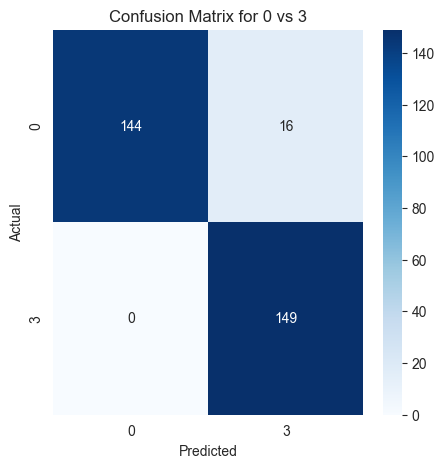

In [26]:
# model, val_generator = train_binary_classifier(class_pairs[0][0], class_pairs[0][1])
evaluate_model(model, val_generator, 0, 3)

In [27]:
# Get predicted labels
val_labels = val_generator.labels  # True labels
y_pred = (model.predict(val_generator).ravel() > 0.5).astype(int)  # Binary classification predictions

# Get image filenames from the generator
image_filenames = val_generator.filenames

# Separate correctly classified and misclassified images for label 2 (encoded as 1)
correctly_classified = []
misclassified = []

for filename, true_label, pred_label in zip(image_filenames, val_labels, y_pred):
    if true_label == 0:  # Only considering images of class 2 (encoded as 1)
        if pred_label == 0:
            correctly_classified.append([filename, "0"])  # Correctly classified as 2
        else:
            misclassified.append([filename, "3"])  # Misclassified as another class

# Create DataFrames
df_correct = pd.DataFrame(correctly_classified, columns=["ID Code", "Pred Label"])
df_misclassified = pd.DataFrame(misclassified, columns=["ID Code", "Missclassified Label"])

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 540ms/step


In [28]:
df_correct

,ID Code,Pred Label
0,f531232ecb55.png,0
1,58f07741ee3b.png,0
2,a73d012c4c38.png,0
3,1dfe599d12a9.png,0
4,2cfe8703f265.png,0
...,...,...
139,e4dcca36ceb4.png,0
140,d871895742b1.png,0
141,4c60f6fcea75.png,0
142,db52626d450c.png,0


In [29]:
df_misclassified

,ID Code,Missclassified Label
0,3732de8b416f.png,3
1,6ccfdb031184.png,3
2,05b1bb2bdb81.png,3
3,beb00fa6e7c9.png,3
4,291f581d365e.png,3
5,436fa3fd145a.png,3
6,8be6629a6039.png,3
7,57f5ad4b5b29.png,3
8,74898f372d2b.png,3
9,badb5ff8d3c7.png,3


In [30]:
pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
# Save to separate Excel files
df_correct.to_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/correctly_classified_label_0.xlsx", index=False)
df_misclassified.to_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/misclassified_label_0.xlsx", index=False)